# Optuna Hyperparameter Search Results Analysis

This notebook analyzes the results from the Optuna hyperparameter search for Deep SDF reconstruction.

**Goal:** Find the best trial (lowest errors) and corresponding hyperparameters.

## 1. Import Required Libraries

In [15]:
import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Set Directory Path

In [16]:
# Path to Optuna search results
results_dir = "/home/jakaria/INR/Deep3DComp/examples/CALSNIC_control_L/optuna_reconstruction_search"

# Check if directory exists
if os.path.exists(results_dir):
    print(f"✓ Results directory found: {results_dir}")
    
    # List trial directories
    trial_dirs = sorted(glob.glob(os.path.join(results_dir, "optuna_trial_*")))
    print(f"✓ Found {len(trial_dirs)} trial directories")
else:
    print(f"✗ Directory not found: {results_dir}")

✓ Results directory found: /home/jakaria/INR/Deep3DComp/examples/CALSNIC_control_L/optuna_reconstruction_search
✓ Found 206 trial directories


## 3. Load Trial Results from JSON Files

In [17]:
def load_trial_data(trial_dir):
    """
    Load trial results from trial_results.json and epoch_metrics.json
    """
    trial_num = int(os.path.basename(trial_dir).split("_")[-1])
    
    # Load main results
    results_file = os.path.join(trial_dir, "trial_results.json")
    epoch_metrics_file = os.path.join(trial_dir, "epoch_metrics.json")
    
    if not os.path.exists(results_file):
        return None
    
    with open(results_file, 'r') as f:
        results = json.load(f)
    
    # Load epoch metrics if available
    epoch_metrics = None
    if os.path.exists(epoch_metrics_file):
        with open(epoch_metrics_file, 'r') as f:
            epoch_metrics = json.load(f)
    
    return {
        'trial_num': trial_num,
        'results': results,
        'epoch_metrics': epoch_metrics
    }

# Load all trials
all_trials = []
for trial_dir in trial_dirs:
    trial_data = load_trial_data(trial_dir)
    if trial_data is not None:
        all_trials.append(trial_data)

print(f"✓ Successfully loaded {len(all_trials)} trial results")

✓ Successfully loaded 186 trial results


## 4. Extract Trial Parameters and Errors at Epoch 150

In [18]:
# Extract data for each trial
trial_data_list = []

for trial in all_trials:
    trial_num = trial['trial_num']
    results = trial['results']
    epoch_metrics = trial['epoch_metrics']
    
    # Get parameters
    params = results.get('parameters', {})
    
    # Get final metrics
    final_metrics = results.get('final_metrics', {})
    
    # Find epoch 150 data
    epoch_150_train_loss = None
    epoch_150_sdf_loss = None
    epoch_150_train_chamfer = None
    epoch_150_test_chamfer = None
    
    if epoch_metrics and 'epochs' in epoch_metrics:
        epochs = epoch_metrics['epochs']
        if 150 in epochs or 149 in epochs:  # Check both (0-indexed vs 1-indexed)
            # Try to find epoch 150
            try:
                idx_150 = epochs.index(150)
            except ValueError:
                try:
                    idx_150 = epochs.index(149)
                except ValueError:
                    # Use last epoch if 150 not found
                    idx_150 = -1
            
            # Extract metrics at epoch 150
            if 'train_loss' in epoch_metrics and len(epoch_metrics['train_loss']) > idx_150:
                epoch_150_train_loss = epoch_metrics['train_loss'][idx_150]
            
            if 'train_sdf_loss' in epoch_metrics and len(epoch_metrics['train_sdf_loss']) > idx_150:
                epoch_150_sdf_loss = epoch_metrics['train_sdf_loss'][idx_150]
            
            if 'train_chamfer' in epoch_metrics and len(epoch_metrics['train_chamfer']) > idx_150:
                epoch_150_train_chamfer = epoch_metrics['train_chamfer'][idx_150]
            
            if 'test_chamfer' in epoch_metrics and len(epoch_metrics['test_chamfer']) > idx_150:
                epoch_150_test_chamfer = epoch_metrics['test_chamfer'][idx_150]
    
    # Create trial data dictionary
    trial_info = {
        'trial_number': trial_num,
        'epoch_150_train_loss': epoch_150_train_loss,
        'epoch_150_sdf_loss': epoch_150_sdf_loss,
        'epoch_150_train_chamfer': epoch_150_train_chamfer,
        'epoch_150_test_chamfer': epoch_150_test_chamfer,
        'final_train_loss': final_metrics.get('train_loss'),
        'final_sdf_loss': final_metrics.get('train_sdf_loss'),
        'final_train_chamfer': final_metrics.get('train_chamfer_distance'),
        'final_test_chamfer': final_metrics.get('test_chamfer_distance'),
        'optimization_metric': final_metrics.get('optimization_metric'),
        'CodeLength': params.get('CodeLength'),
        'ClampingDistance': params.get('ClampingDistance'),
        'CodeRegularizationLambda': params.get('CodeRegularizationLambda'),
        'GradientClipNorm': params.get('GradientClipNorm'),
        'ScenesPerBatch': params.get('ScenesPerBatch'),
        'network_lr_initial': params.get('network_lr_initial'),
        'latent_lr_initial': params.get('latent_lr_initial'),
        'n_layers': params.get('n_layers'),
        'hidden_dim': params.get('hidden_dim'),
        'dropout_prob': params.get('dropout_prob'),
        'latent_in_layer': params.get('latent_in_layer'),
    }
    
    trial_data_list.append(trial_info)

# Create DataFrame
df = pd.DataFrame(trial_data_list)

print(f"✓ Extracted data from {len(df)} trials")
print(f"\\nDataFrame shape: {df.shape}")
print(f"\\nColumns: {list(df.columns)}")

✓ Extracted data from 186 trials
\nDataFrame shape: (186, 21)
\nColumns: ['trial_number', 'epoch_150_train_loss', 'epoch_150_sdf_loss', 'epoch_150_train_chamfer', 'epoch_150_test_chamfer', 'final_train_loss', 'final_sdf_loss', 'final_train_chamfer', 'final_test_chamfer', 'optimization_metric', 'CodeLength', 'ClampingDistance', 'CodeRegularizationLambda', 'GradientClipNorm', 'ScenesPerBatch', 'network_lr_initial', 'latent_lr_initial', 'n_layers', 'hidden_dim', 'dropout_prob', 'latent_in_layer']


## 5. Find Trial with Lowest SDF Error at Epoch 150

In [19]:
# Filter out trials with no epoch 150 SDF loss data
df_with_sdf = df.dropna(subset=['epoch_150_sdf_loss'])

if len(df_with_sdf) > 0:
    # Find trial with lowest SDF loss
    best_sdf_trial = df_with_sdf.loc[df_with_sdf['epoch_150_sdf_loss'].idxmin()]
    
    print("="*80)
    print("TRIAL WITH LOWEST SDF ERROR AT EPOCH 150")
    print("="*80)
    print(f"Trial Number: {best_sdf_trial['trial_number']}")
    print(f"Epoch 150 SDF Loss: {best_sdf_trial['epoch_150_sdf_loss']:.6f}")
    print(f"Epoch 150 Total Loss: {best_sdf_trial['epoch_150_train_loss']:.6f}")
    print(f"Epoch 150 Train Chamfer: {best_sdf_trial['epoch_150_train_chamfer']:.6f}" if pd.notna(best_sdf_trial['epoch_150_train_chamfer']) else "")
    print(f"Epoch 150 Test Chamfer: {best_sdf_trial['epoch_150_test_chamfer']:.6f}" if pd.notna(best_sdf_trial['epoch_150_test_chamfer']) else "")
    print("\\n" + "-"*80)
    print("HYPERPARAMETERS:")
    print("-"*80)
    print(f"CodeLength: {best_sdf_trial['CodeLength']}")
    print(f"ClampingDistance: {best_sdf_trial['ClampingDistance']}")
    print(f"CodeRegularizationLambda: {best_sdf_trial['CodeRegularizationLambda']}")
    print(f"GradientClipNorm: {best_sdf_trial['GradientClipNorm']}")
    print(f"ScenesPerBatch: {best_sdf_trial['ScenesPerBatch']}")
    print(f"Network LR Initial: {best_sdf_trial['network_lr_initial']}")
    print(f"Latent LR Initial: {best_sdf_trial['latent_lr_initial']}")
    print(f"Number of Layers: {best_sdf_trial['n_layers']}")
    print(f"Hidden Dimension: {best_sdf_trial['hidden_dim']}")
    print(f"Dropout Probability: {best_sdf_trial['dropout_prob']}")
    print(f"Latent Injection Layer: {best_sdf_trial['latent_in_layer']}")
    print("="*80)
else:
    print("No trials with epoch 150 SDF loss data found")

TRIAL WITH LOWEST SDF ERROR AT EPOCH 150
Trial Number: 60
Epoch 150 SDF Loss: 0.012192
Epoch 150 Total Loss: 0.012192


\n--------------------------------------------------------------------------------
HYPERPARAMETERS:
--------------------------------------------------------------------------------
CodeLength: 16
ClampingDistance: 0.05
CodeRegularizationLambda: 1.4588184698941938e-05
GradientClipNorm: 1.0
ScenesPerBatch: 32
Network LR Initial: 0.001003366628282104
Latent LR Initial: 0.004237014585245094
Number of Layers: 6
Hidden Dimension: 256
Dropout Probability: 0.2
Latent Injection Layer: 2


## 6. Find Trial with Lowest Total Loss at Epoch 150

In [20]:
# Filter out trials with no epoch 150 total loss data
df_with_loss = df.dropna(subset=['epoch_150_train_loss'])

if len(df_with_loss) > 0:
    # Find trial with lowest total loss
    best_loss_trial = df_with_loss.loc[df_with_loss['epoch_150_train_loss'].idxmin()]
    
    print("="*80)
    print("TRIAL WITH LOWEST TOTAL LOSS AT EPOCH 150")
    print("="*80)
    print(f"Trial Number: {best_loss_trial['trial_number']}")
    print(f"Epoch 150 Total Loss: {best_loss_trial['epoch_150_train_loss']:.6f}")
    print(f"Epoch 150 SDF Loss: {best_loss_trial['epoch_150_sdf_loss']:.6f}")
    print(f"Epoch 150 Train Chamfer: {best_loss_trial['epoch_150_train_chamfer']:.6f}" if pd.notna(best_loss_trial['epoch_150_train_chamfer']) else "")
    print(f"Epoch 150 Test Chamfer: {best_loss_trial['epoch_150_test_chamfer']:.6f}" if pd.notna(best_loss_trial['epoch_150_test_chamfer']) else "")
    print("\\n" + "-"*80)
    print("HYPERPARAMETERS:")
    print("-"*80)
    print(f"CodeLength: {best_loss_trial['CodeLength']}")
    print(f"ClampingDistance: {best_loss_trial['ClampingDistance']}")
    print(f"CodeRegularizationLambda: {best_loss_trial['CodeRegularizationLambda']}")
    print(f"GradientClipNorm: {best_loss_trial['GradientClipNorm']}")
    print(f"ScenesPerBatch: {best_loss_trial['ScenesPerBatch']}")
    print(f"Network LR Initial: {best_loss_trial['network_lr_initial']}")
    print(f"Latent LR Initial: {best_loss_trial['latent_lr_initial']}")
    print(f"Number of Layers: {best_loss_trial['n_layers']}")
    print(f"Hidden Dimension: {best_loss_trial['hidden_dim']}")
    print(f"Dropout Probability: {best_loss_trial['dropout_prob']}")
    print(f"Latent Injection Layer: {best_loss_trial['latent_in_layer']}")
    print("="*80)
else:
    print("No trials with epoch 150 total loss data found")

TRIAL WITH LOWEST TOTAL LOSS AT EPOCH 150
Trial Number: 60
Epoch 150 Total Loss: 0.012192
Epoch 150 SDF Loss: 0.012192


\n--------------------------------------------------------------------------------
HYPERPARAMETERS:
--------------------------------------------------------------------------------
CodeLength: 16
ClampingDistance: 0.05
CodeRegularizationLambda: 1.4588184698941938e-05
GradientClipNorm: 1.0
ScenesPerBatch: 32
Network LR Initial: 0.001003366628282104
Latent LR Initial: 0.004237014585245094
Number of Layers: 6
Hidden Dimension: 256
Dropout Probability: 0.2
Latent Injection Layer: 2


## 7. Display Top 10 Trials by Different Metrics

In [21]:
# Top 10 by SDF Loss at Epoch 150
print("\\n" + "="*80)
print("TOP 10 TRIALS BY SDF LOSS AT EPOCH 150")
print("="*80)
if len(df_with_sdf) > 0:
    top_10_sdf = df_with_sdf.nsmallest(10, 'epoch_150_sdf_loss')[
        ['trial_number', 'epoch_150_sdf_loss', 'epoch_150_train_loss', 'CodeLength', 'hidden_dim', 'n_layers']
    ]
    print(top_10_sdf.to_string(index=False))
else:
    print("No data available")

print("\\n" + "="*80)
print("TOP 10 TRIALS BY TOTAL LOSS AT EPOCH 150")
print("="*80)
if len(df_with_loss) > 0:
    top_10_loss = df_with_loss.nsmallest(10, 'epoch_150_train_loss')[
        ['trial_number', 'epoch_150_train_loss', 'epoch_150_sdf_loss', 'CodeLength', 'hidden_dim', 'n_layers']
    ]
    print(top_10_loss.to_string(index=False))
else:
    print("No data available")

\n================================================================================
TOP 10 TRIALS BY SDF LOSS AT EPOCH 150
 trial_number  epoch_150_sdf_loss  epoch_150_train_loss  CodeLength  hidden_dim  n_layers
           60            0.012192              0.012192          16         256         6
          110            0.012360              0.012360          64         256         8
           13            0.012749              0.012749          32         256         8
           73            0.012795              0.012795          64         256         6
           86            0.012874              0.012874          64         256         6
           38            0.012906              0.012906         128         256         7
           78            0.013024              0.013024          16         256         6
           70            0.013167              0.013167          64         256         8
          111            0.013278              0.013278          64 

## 8. Visualize Error Metrics Across All Trials

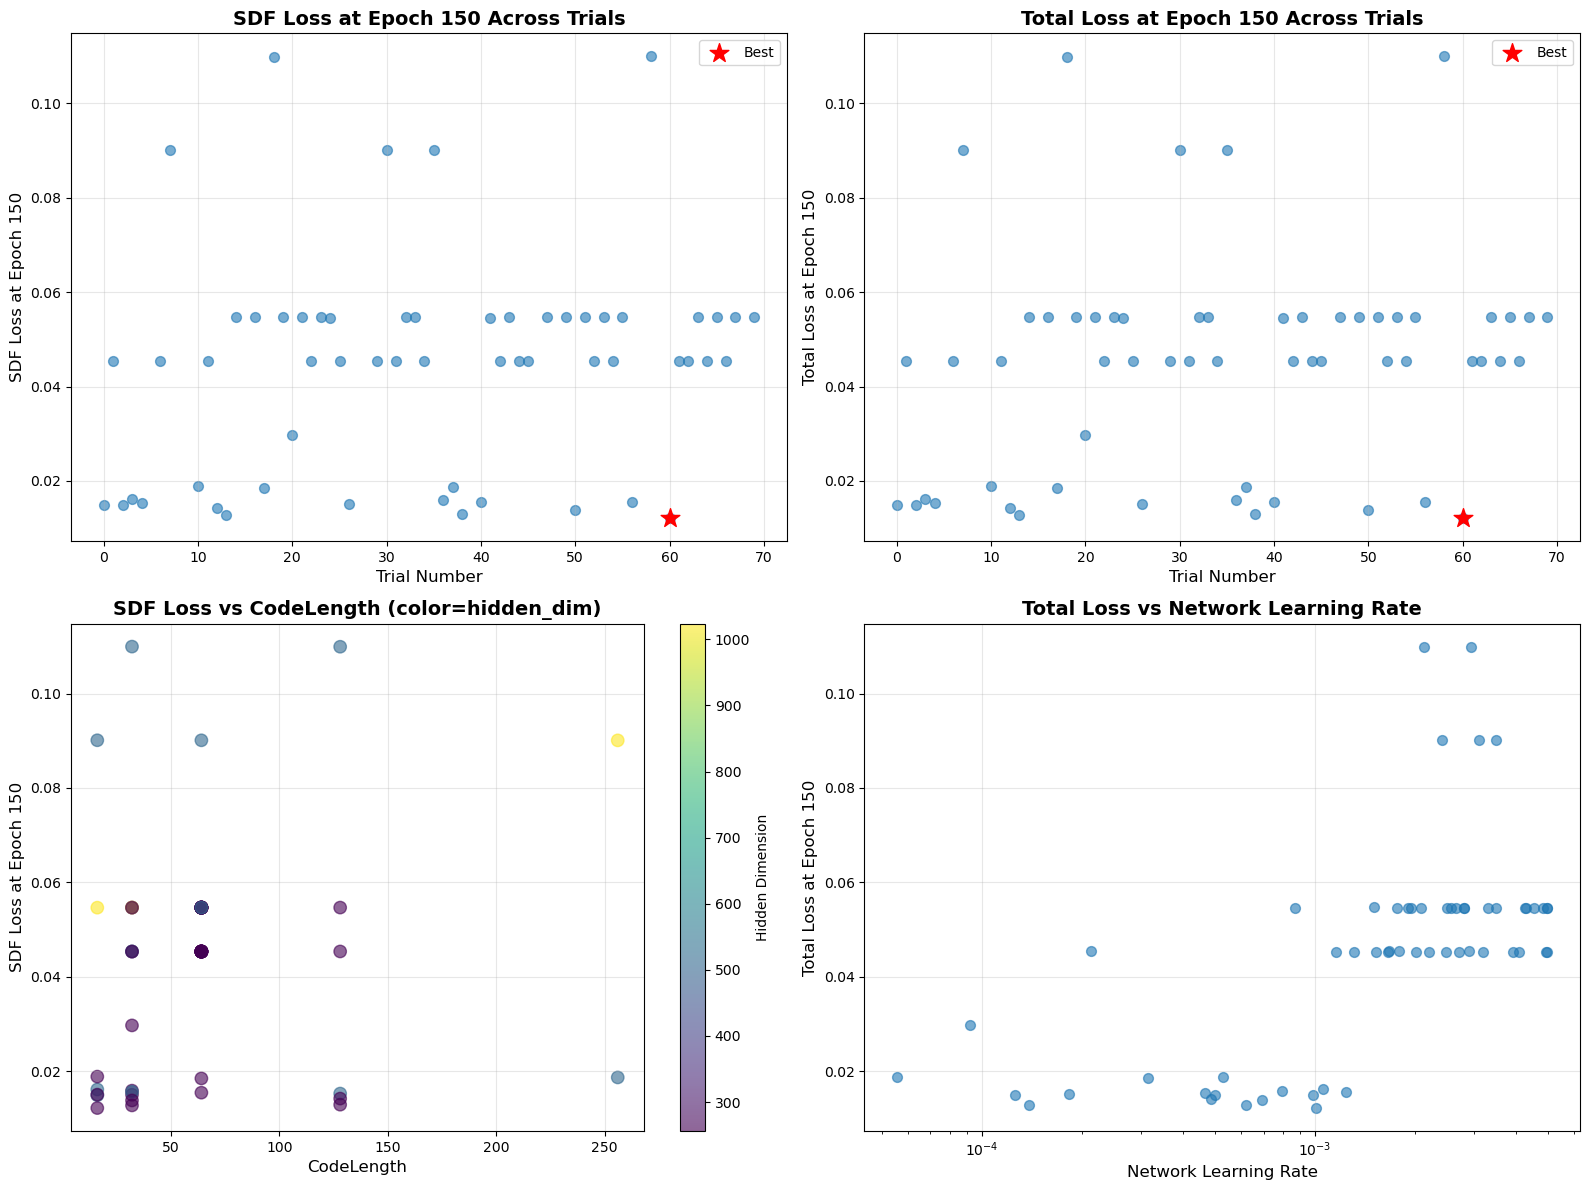

\n✓ Visualizations complete!


In [8]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: SDF Loss at Epoch 150
if len(df_with_sdf) > 0:
    axes[0, 0].scatter(df_with_sdf['trial_number'], df_with_sdf['epoch_150_sdf_loss'], alpha=0.6, s=50)
    axes[0, 0].set_xlabel('Trial Number', fontsize=12)
    axes[0, 0].set_ylabel('SDF Loss at Epoch 150', fontsize=12)
    axes[0, 0].set_title('SDF Loss at Epoch 150 Across Trials', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Highlight best trial
    best_idx = df_with_sdf['epoch_150_sdf_loss'].idxmin()
    axes[0, 0].scatter(df_with_sdf.loc[best_idx, 'trial_number'], 
                      df_with_sdf.loc[best_idx, 'epoch_150_sdf_loss'], 
                      color='red', s=200, marker='*', label='Best', zorder=5)
    axes[0, 0].legend()

# Plot 2: Total Loss at Epoch 150
if len(df_with_loss) > 0:
    axes[0, 1].scatter(df_with_loss['trial_number'], df_with_loss['epoch_150_train_loss'], alpha=0.6, s=50)
    axes[0, 1].set_xlabel('Trial Number', fontsize=12)
    axes[0, 1].set_ylabel('Total Loss at Epoch 150', fontsize=12)
    axes[0, 1].set_title('Total Loss at Epoch 150 Across Trials', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Highlight best trial
    best_idx = df_with_loss['epoch_150_train_loss'].idxmin()
    axes[0, 1].scatter(df_with_loss.loc[best_idx, 'trial_number'], 
                      df_with_loss.loc[best_idx, 'epoch_150_train_loss'], 
                      color='red', s=200, marker='*', label='Best', zorder=5)
    axes[0, 1].legend()

# Plot 3: SDF Loss vs CodeLength
if len(df_with_sdf) > 0:
    scatter = axes[1, 0].scatter(df_with_sdf['CodeLength'], df_with_sdf['epoch_150_sdf_loss'], 
                                 c=df_with_sdf['hidden_dim'], cmap='viridis', alpha=0.6, s=80)
    axes[1, 0].set_xlabel('CodeLength', fontsize=12)
    axes[1, 0].set_ylabel('SDF Loss at Epoch 150', fontsize=12)
    axes[1, 0].set_title('SDF Loss vs CodeLength (color=hidden_dim)', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, 0], label='Hidden Dimension')

# Plot 4: Loss vs Learning Rate
if len(df_with_loss) > 0:
    axes[1, 1].scatter(df_with_loss['network_lr_initial'], df_with_loss['epoch_150_train_loss'], 
                      alpha=0.6, s=50, label='Train Loss')
    axes[1, 1].set_xlabel('Network Learning Rate', fontsize=12)
    axes[1, 1].set_ylabel('Total Loss at Epoch 150', fontsize=12)
    axes[1, 1].set_title('Total Loss vs Network Learning Rate', fontsize=14, fontweight='bold')
    axes[1, 1].set_xscale('log')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\n✓ Visualizations complete!")

## 9. Summary Statistics

In [9]:
# Summary statistics
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

if len(df_with_sdf) > 0:
    print("\\nSDF Loss at Epoch 150:")
    print(f"  Min:    {df_with_sdf['epoch_150_sdf_loss'].min():.6f}")
    print(f"  Max:    {df_with_sdf['epoch_150_sdf_loss'].max():.6f}")
    print(f"  Mean:   {df_with_sdf['epoch_150_sdf_loss'].mean():.6f}")
    print(f"  Median: {df_with_sdf['epoch_150_sdf_loss'].median():.6f}")
    print(f"  Std:    {df_with_sdf['epoch_150_sdf_loss'].std():.6f}")

if len(df_with_loss) > 0:
    print("\\nTotal Loss at Epoch 150:")
    print(f"  Min:    {df_with_loss['epoch_150_train_loss'].min():.6f}")
    print(f"  Max:    {df_with_loss['epoch_150_train_loss'].max():.6f}")
    print(f"  Mean:   {df_with_loss['epoch_150_train_loss'].mean():.6f}")
    print(f"  Median: {df_with_loss['epoch_150_train_loss'].median():.6f}")
    print(f"  Std:    {df_with_loss['epoch_150_train_loss'].std():.6f}")

print("\\n" + "="*80)

SUMMARY STATISTICS
\nSDF Loss at Epoch 150:
  Min:    0.012192
  Max:    0.109945
  Mean:   0.044384
  Median: 0.045354
  Std:    0.023197
\nTotal Loss at Epoch 150:
  Min:    0.012192
  Max:    0.109945
  Mean:   0.044384
  Median: 0.045354
  Std:    0.023197
\n================================================================================
